<a href="https://colab.research.google.com/github/moonidil/MLSentimentClassification/blob/main/cw1partb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MA6700 Part B: IMDB sentiment clasification
This notebook builds a classical Ml model that classifies IMDB movie reviews as positive or negative using the Keras IMDB dataset.

-Idil Cabdullahi
K2372399

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.datasets import imdb
import re
import warnings
warnings.filterwarnings('ignore')

print("The libraries have loaded successfully")

The libraries have loaded successfully


## 1.Load Dataset

The keras IMDB dataset has 25000 training and 25000 test movie reviews that are already split and labeled 0=negative and 1=positive.

Thing is, Keras stores reviews as integer sequences with each word replaced by its frequency rank so I'll have to convert them back to text for the classical NLP preprocessing.

In [23]:
#load dataset. get all words
#num_words = None means to keep all words, not just top-N frequent
(X_train_int, y_train), (X_test_int, y_test) = imdb.load_data(num_words = None)

print(f"Num of training samples: {len(X_train_int)}")
print(f"Num of test samples: {len(X_test_int)}")
print(f"\nClass distribution (train):")
print(f"  Negative (0): {(y_train == 0).sum()}")
print(f"  Positive (1): {(y_train == 1).sum()}")
print(f"\nClass balance: {(y_train == 1).sum() / len(y_train) * 100:.1f}% positive")

Num of training samples: 25000
Num of test samples: 25000

Class distribution (train):
  Negative (0): 12500
  Positive (1): 12500

Class balance: 50.0% positive


In [24]:
#look at an encoded review
print("The first review (encoded as integers):")
print(X_train_int[0][:50])  #first 50 word indices
print(f"\nReview length: {len(X_train_int[0])} words")

print(f"Label: {y_train[0]} (positive)")

The first review (encoded as integers):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447]

Review length: 218 words
Label: 1 (positive)


The datasets format is that each review is a list of integers where each integer represents a word. Lower numbers = more frequent words, for example, 1="the", 2="and" so I decode these back to text for preprocessing

In [25]:
#get the word index mapping function, word -> integer
word_index = imdb.get_word_index()

#reverse it to get integer -> word
#Keras adds offset of 3 to indices 0 = padding, 1 = start, 2 = unknown

reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'

print(f"Vocabulary size: {len(word_index)} unique words")
print(f"\nMost frequent words:")

for i in range(3, 13):
    print(f"  {i}: {reverse_word_index.get(i, '?')}")

Vocabulary size: 88584 unique words

Most frequent words:
  3: ?
  4: the
  5: and
  6: a
  7: of
  8: to
  9: is
  10: br
  11: in
  12: it


In [26]:
#function to decode integer sequences back to text
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded_review])

#decode all reviews
print("Decoding training reviews...")
X_train_text = [decode_review(review) for review in X_train_int]

print("Decoding test reviews...")
X_test_text = [decode_review(review) for review in X_test_int]

print("\nAn example decoded review:")
print(X_train_text[0][:500])  #show first 500 characters as example
print(f"...\nLabel: {y_train[0]} (positive)")

Decoding training reviews...
Decoding test reviews...

An example decoded review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and 
...
Label: 1 (positive)


## 2. Exploratory data analysis

Understanding reviews' characteristics before preprocessing

In [27]:
#review length distribution
train_lengths = [len(review.split()) for review in X_train_text]
test_lengths = [len(review.split()) for review in X_test_text]

print("Reviewing length statistics (of train set):")
print(f"  Mean: {np.mean(train_lengths):.1f} words")
print(f"  Median: {np.median(train_lengths):.1f} words")
print(f"  Min: {np.min(train_lengths)} words")
print(f"  Max: {np.max(train_lengths)} words")
print(f"  Std: {np.std(train_lengths):.1f} words")

Reviewing length statistics (of train set):
  Mean: 238.7 words
  Median: 178.0 words
  Min: 11 words
  Max: 2494 words
  Std: 176.5 words


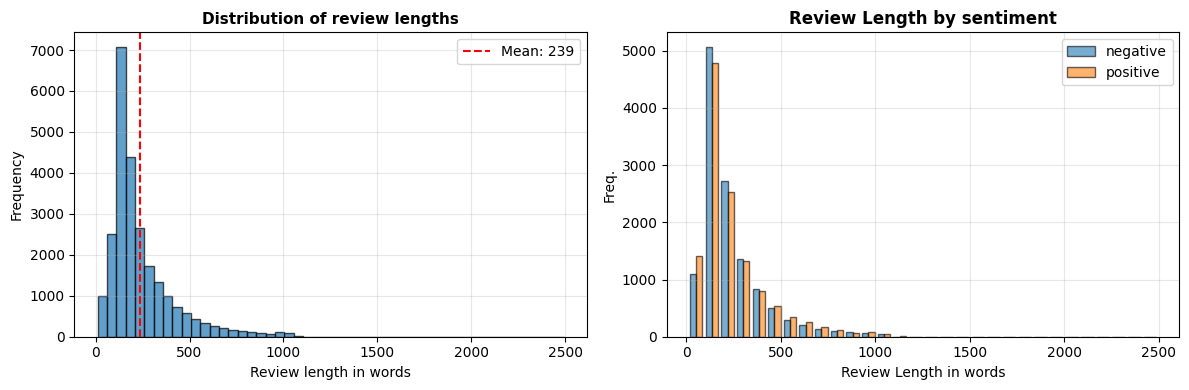


Mean length - Negative: 235.9 words
Mean length - Positive: 241.6 words
Difference: 5.7 words


In [28]:
#plotting the length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_lengths, bins=50, alpha=0.7, edgecolor='black') #histogram as continuous data
axes[0].axvline(np.mean(train_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(train_lengths):.0f}')
axes[0].set_xlabel('Review length in words', fontsize=10)
axes[0].set_ylabel('Freq.', fontsize=10)
axes[0].set_title('Distribution of review lengths', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

#compare lengths of positive vs negative
pos_lengths = [train_lengths[i] for i in range(len(y_train)) if y_train[i] == 1]
neg_lengths = [train_lengths[i] for i in range(len(y_train)) if y_train[i] == 0]

axes[1].hist([neg_lengths, pos_lengths], bins=30, alpha=0.6, label=['negative', 'positive'], edgecolor='black')
axes[1].set_xlabel('Review Length in words', fontsize=10)
axes[1].set_ylabel('Freq.', fontsize=10)
axes[1].set_title('Review Length by sentiment', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean length - Negative: {np.mean(neg_lengths):.1f} words")
print(f"Mean length - Positive: {np.mean(pos_lengths):.1f} words")
print(f"Difference: {abs(np.mean(pos_lengths) - np.mean(neg_lengths)):.1f} words")

My observations:
- Most reviews are 100 to 300 words which seems usual for online reviews
- Some outliers are very long, greater than >1000 words
- Pos and neg reviews have similar length distributions
- ^ Looking at length alone won't distinguish the sentiment well

## 3. Text preprocessing

Classical NLP preprocessing steps: remove special tokens (`<START>`, `<UNK>`, `<PAD>`), convert to lowercase, remove punctuation and numbers, and remove extra whitespace

I am not doing stemming/lemmatisation as it'll lose nuance (like 'good' vs 'best' vs 'better'), stopword removal as words like 'not', 'but' are crucial for sentiment, and extreme length filtering as the model can decide what's useful

In [ ]:
import re

def clean_text(text):
    """Clean the review text by removing special tokens, punctuation and normalising"""
    #remove special tokens
    text = text.replace('<START>', '').replace('<UNK>', '').replace('<PAD>', '')

    #convert to lowercase
    text = text.lower()

    #get rid of punctuation and numbers, leave only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    #get rid of extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

#then test the function on one review
print("Before cleaning:")
print(X_train_text[0][:200])
print("\nAfter cleaning:")
print(clean_text(X_train_text[0])[:200])